Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [ ]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [1]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [2]:
# Specify file paths
data_file = "20251212-sam-triggerDNA-test_biotek-cdk.txt"
platemap_file = "20251212-triggerDNA-platemap.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Plate,Clock Time,Date,Experiment Name,...,Ribosome Vol (uL),SMix Vol (uL),tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),PPK Vol (uL),polyP Vol (uL),Mg-Ace Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:00,B2,285.00,B,2,GFP-G50,Plate 1,2025-12-12 13:45:42,20251212,triggerDNA-test,...,1.80,3,1,0.24,0.50,NaN,NaN,NaN,2.26,10
1,0 days 00:05:00,B2,274.00,B,2,GFP-G50,Plate 1,2025-12-12 13:50:42,20251212,triggerDNA-test,...,1.80,3,1,0.24,0.50,NaN,NaN,NaN,2.26,10
2,0 days 00:10:00,B2,590.00,B,2,GFP-G50,Plate 1,2025-12-12 13:55:42,20251212,triggerDNA-test,...,1.80,3,1,0.24,0.50,NaN,NaN,NaN,2.26,10
3,0 days 00:15:00,B2,2066.00,B,2,GFP-G50,Plate 1,2025-12-12 14:00:42,20251212,triggerDNA-test,...,1.80,3,1,0.24,0.50,NaN,NaN,NaN,2.26,10
4,0 days 00:20:00,B2,4466.00,B,2,GFP-G50,Plate 1,2025-12-12 14:05:42,20251212,triggerDNA-test,...,1.80,3,1,0.24,0.50,NaN,NaN,NaN,2.26,10


## Plot Raw Curves

In [3]:
# data.Read.unique()
data=data[data.Read == 'GFP-G50']

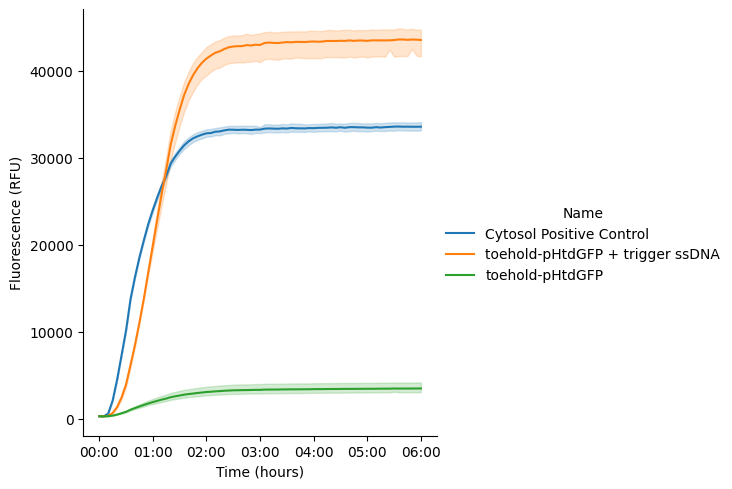

In [4]:
g = pr.plot_curves(data=data[data.Read == 'GFP-G50'])
g.savefig('kinetic.png')

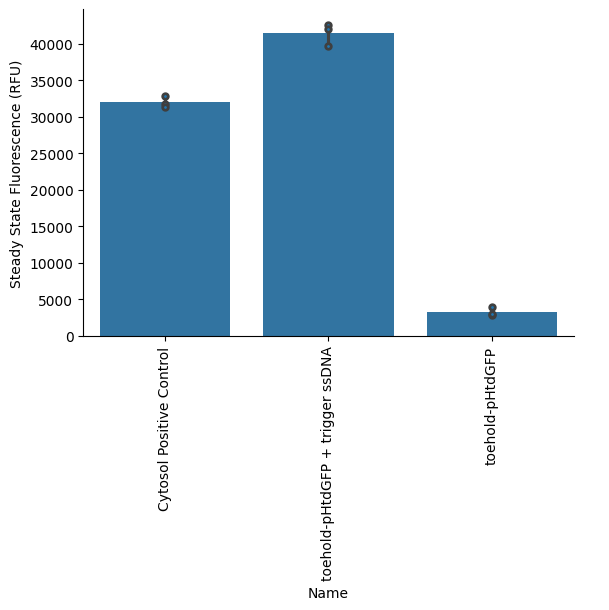

In [5]:
S= pr.plot_steadystate(data)
S.savefig('endpoint')

## Normalize Data

In [30]:
#data = pr.normalize_data_to_controls(data, ctrl_name = '10 uM HPTS')

Now replot your curves to see them normalized

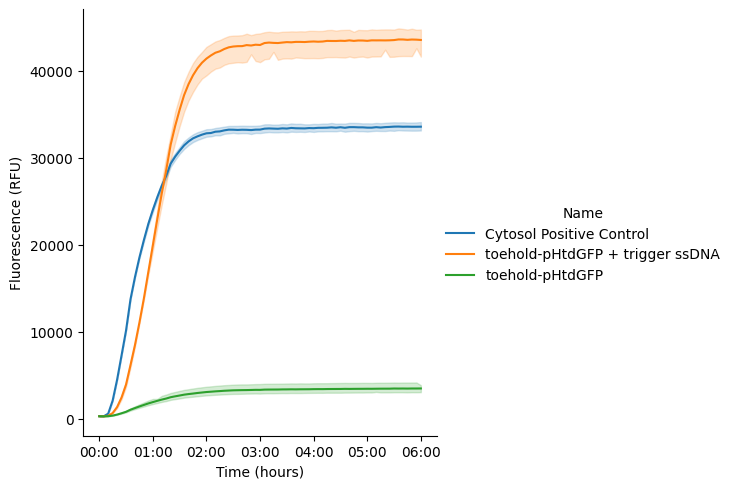

In [6]:
g = pr.plot_curves(data=data)

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [7]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Name'],  # Group by experimental condition
)

kinetics.head()

PROVIDING AVERAGED KINETICS


Velocity                    \
                                                     Time     Data      Max   
Name                                                                          
Cytosol Positive Control        0 days 00:40:44.310633639 16848.15 32721.13   
toehold-pHtdGFP                 0 days 00:48:45.312268724  1735.65  2056.96   
toehold-pHtdGFP + trigger ssDNA 0 days 01:01:34.855997724 21812.60 38855.35   

                                                        Lag          \
                                                       Time    Data   
Name                                                                  
Cytosol Positive Control          0 days 00:09:50.825852175 2250.32   
toehold-pHtdGFP                 -1 days +23:57:55.089159831  116.18   
toehold-pHtdGFP + trigger ssDNA   0 days 00:27:49.363820262 3902.76   

                                             Steady State           \
                                                     Time     Data   
Name                                                                 
Cytosol Positive Control        0 days 01:26:13.047051615 32011.49   
toehold-pHtdGFP                 0 days 02:03:35.910176639  3297.73   
toehold-pHtdGFP + trigger ssDNA 0 days 01:51:16.825056805 41443.95   

                                                                               Fit  \
                                                                            params   
Name                                                                                 
Cytosol Positive Control         [33696.3072042378, 3.8851204402844712, 0.67897...   
toehold-pHtdGFP                  [3471.2919502285295, 2.3619279920381273, 0.812...   
toehold-pHtdGFP + trigger ssDNA  [43625.20606812134, 3.5590700435616074, 1.0263...   

                                             
                                 R^2  drift  
Name                                         
Cytosol Positive Control        1.00 363.76  
toehold-pHtdGFP                 1.00  52.59  
toehold-pHtdGFP + trigger ssDNA 1.00 268.81

## Visualize Fits on Individual Wells

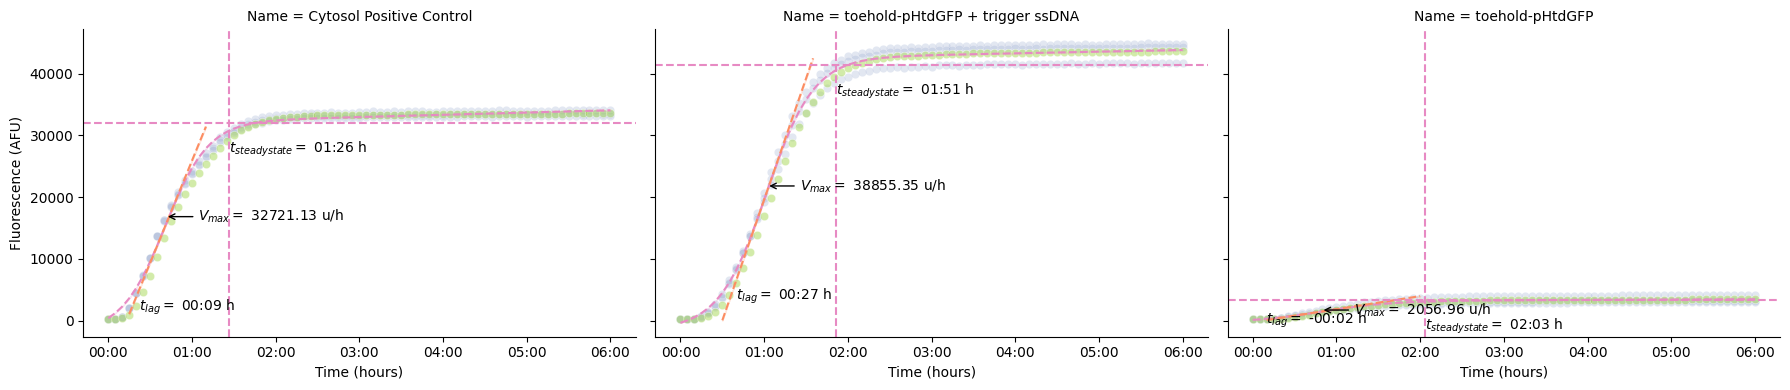

In [8]:
# Plot kinetic fits 
g, kinetics = pr.plot_kinetics(data, kinetics=kinetics, group_by=["Name"])

## Summary Plots

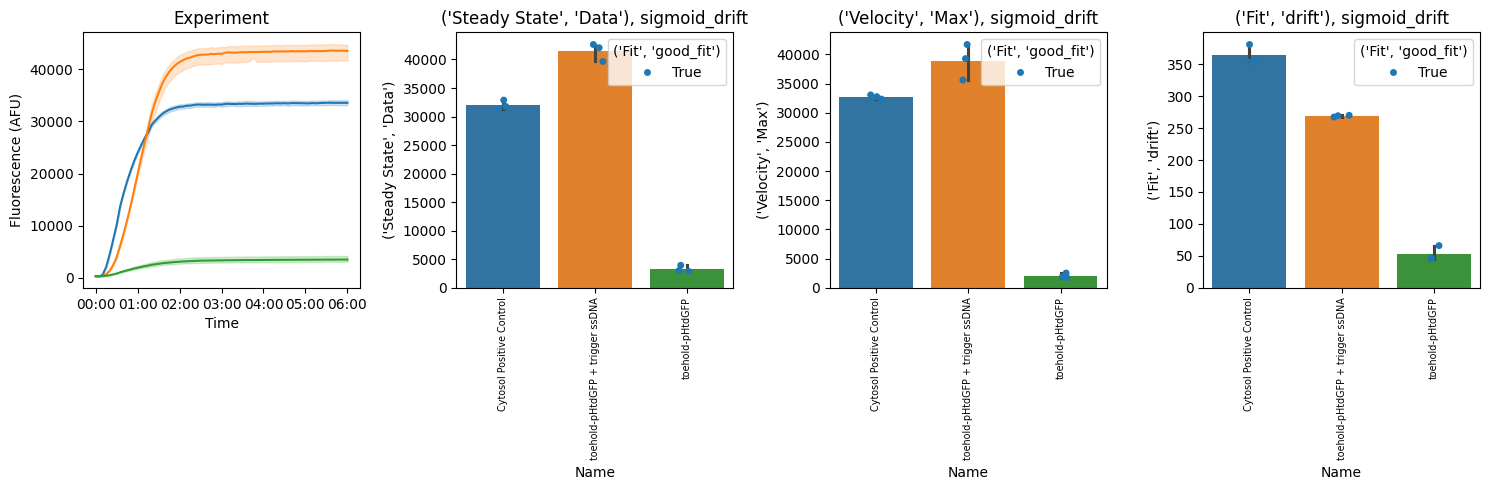

In [9]:
pr.plot_summary(data)

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants